# 📊 **Exploratory Data Analysis — Bitcoin (BTC)**

### 🎯 **Objective**
Explore the Bitcoin **Gold dataset** to understand market behavior and identify patterns associated with **bearish reversals (crashes)**.

### ⚠️ **Target Definition**
A crash is defined as a price drop of more than **10% within the next 7 days**.

- `1` → Crash  
- `0` → No crash  

### 🔬 **EDA Focus**
1.  Distribution of the target (class balance)  
2.  BTC price with crash events  
3.  Drawdown analysis  
4.  Feature distributions  
5.  Correlation between features and target  

### 🚀 **Goal**
Identify signals and patterns that could help predict market reversals.

In [1]:
import math
import random
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

### **1. Distribution of the target (class balance)**  

In [ ]:
df = pd.read_csv("../../data/gold/market/btc_usdt_1d_features.csv", low_memory=False)

DF's infos

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   open_time               3115 non-null   str    
 1   open                    3115 non-null   float64
 2   high                    3115 non-null   float64
 3   low                     3115 non-null   float64
 4   close                   3115 non-null   float64
 5   volume                  3115 non-null   float64
 6   quote_asset_volume      3115 non-null   float64
 7   number_of_trades        3115 non-null   int64  
 8   taker_buy_base_volume   3115 non-null   float64
 9   taker_buy_quote_volume  3115 non-null   float64
 10  return_1d               3115 non-null   float64
 11  return_7d               3115 non-null   float64
 12  volatility_7d           3115 non-null   float64
 13  volatility_30d          3115 non-null   float64
 14  drawdown                3115 non-null   float64
 15

Focus on target column

In [4]:
print(df["target"].value_counts(normalize=True), "\n\n", df["target"].value_counts())

target
0    0.87801
1    0.12199
Name: proportion, dtype: float64 

 target
0    2735
1     380
Name: count, dtype: int64


**Observation:**  
The dataset is imbalanced, with significantly more non-peak observations than peak events.

**Impact:**  
The model may be biased toward predicting the majority class (no peak), leading to misleading accuracy and poor detection of actual peaks (low recall and/or precision).

**Solution:**
- Use appropriate evaluation metrics (precision, recall, F1-score)  
- Apply class weighting to handle imbalance  
- Use resampling techniques (oversampling or undersampling)  
- Adjust the decision threshold to improve detection of peaks  

### **2. BTC price with crash events**

**Bitcoin Price Over Time**

In [5]:
figure=px.line(df, x="open_time", y="close", title="BTC/USDT Price Over Time")
figure.show()

**Bitcoin Price with Peak Events**

In [6]:
figure=px.line(df,x="open_time", y="close")

peaks = df[df["target"] == 1]

figure.add_scatter(
    x=peaks["open_time"], 
    y=peaks["close"],
    mode="markers",
    marker=dict(color="red", size=6),
    name="Peaks"
    )
figure.update_layout(title="BTC/USDT Price Over Time with Peaks")
figure.show()

**Observations:**
- Peaks are mostly located at local price maxima  
- Peaks often precede significant price declines  
- Strong alignment with major market cycles (bull → top → drop)  
- Some peaks occur during minor fluctuations (noise)  
- Overall, peak detection is consistent with market tops  
- Visual inspection confirms that most detected peaks align with actual market tops  
- The definition captures major turning points but may be slightly sensitive to short-term volatility  

**Price Behavior Around Peaks**

*Analyze the typical price pattern before and after randomly selected peak events, using relative returns centered at the peak (t = 0).*


In [7]:
NB_PEAKS_TO_DISPLAY = 5

peaks_position = random.sample(range(len(peaks)), NB_PEAKS_TO_DISPLAY)
random_peaks = peaks.iloc[peaks_position]

# 2 subplots (1 ligne, 2 colonnes)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "Absolute Variation Around Peaks",
        "Relative Returns Around Peaks"
    ]
)

for index, row in random_peaks.iterrows():
    # skip bords
    if index < 7 or index > len(df) - 7:
        continue

    df_slice = df.iloc[index-7:index+7]

    x = list(range(-7, 7))

    # Absolute
    y_abs = df_slice["close"] - row["close"]

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y_abs,
            mode="lines",
            opacity=0.4,
            showlegend=False
        ),
        row=1, col=1
    )

    # Relative
    y_rel = (df_slice["close"] / row["close"]) - 1

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y_rel,
            mode="lines",
            opacity=0.4,
            showlegend=False
        ),
        row=1, col=2
    )

# Layout
fig.update_layout(
    title="Price Behavior Around Peaks (Absolute vs Relative)",
)

fig.update_xaxes(title_text="Days Relative to Peak", row=1, col=1)
fig.update_xaxes(title_text="Days Relative to Peak", row=1, col=2)

fig.update_yaxes(title_text="Price Difference", row=1, col=1)
fig.update_yaxes(title_text="Return vs Peak", row=1, col=2)

fig.show()

**Observations:**
- Prices trend upward before labeled peak events  
- A local maximum is often observed around t = 0, but not always exactly aligned  
- In several cases, higher prices occur before t = 0 (e.g. +10%), indicating the true peak happened earlier  
- This shift is due to the target capturing the onset of a crash rather than the exact market top  
- A decline typically follows, confirming the reversal dynamic  
- The magnitude and timing of drops vary across events, reflecting market noise and heterogeneity  
- Overall, the pattern reflects a transition zone: late uptrend → peak region → decline  

### **3.  Drawdown analysis**

**Visualize drawdown over time**

In [8]:
figure= px.line(df, x="open_time", y="drawdown", title="BTC/USDT Price Over Time")
figure.add_scatter(
    x=peaks["open_time"],
    y=peaks["drawdown"],
    mode="markers",
    marker=dict(color="red", size=6),
    name="Peaks"
)
figure.show()


**Repartition of drawdown**

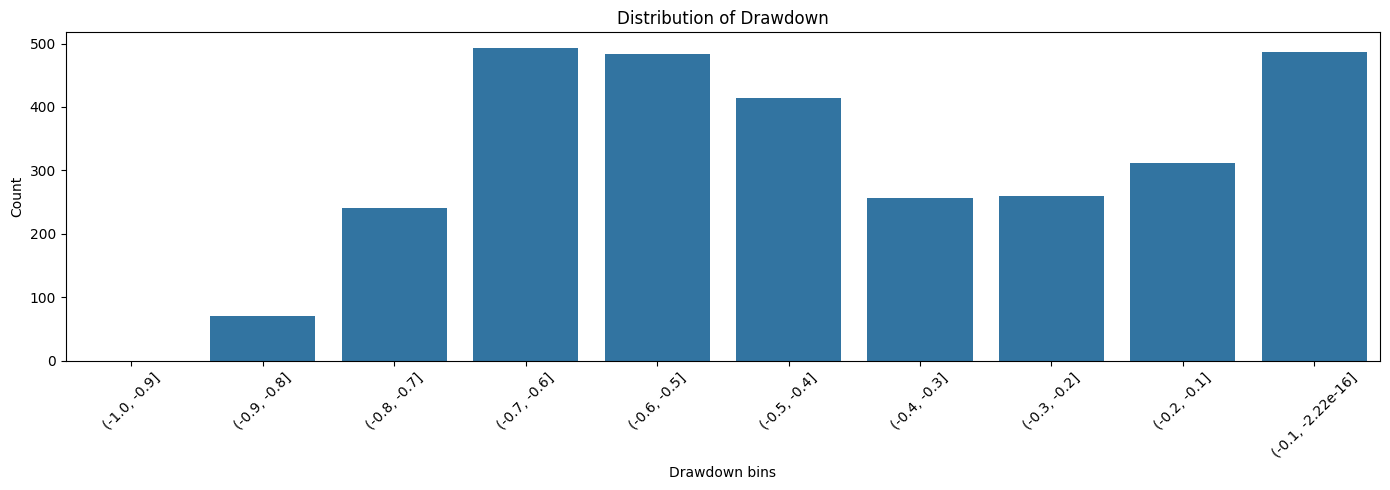

In [9]:
bins = np.arange(-1, 0.1, 0.1)
df["drawdown_bin"] = pd.cut(df["drawdown"], bins=bins)

counts = df["drawdown_bin"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.barplot(x=counts.index.astype(str), y=counts.values)

plt.title("Distribution of Drawdown")
plt.xlabel("Drawdown bins")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

df.drop(columns=["drawdown_bin"], inplace=True)

**Observations:**
- Drawdowns are **persistent and cyclical**, with clear bull/bear regimes.  
- Most values lie in **[-0.7, -0.4]**, indicating frequent medium-to-large corrections.  
- **Extreme crashes (< -0.8)** are rare but present → tail risk.  
- Peaks cluster near **0 drawdown**, showing repeated failed attempts at new highs.  
- Strong **regime-switching behavior** → non-IID, requires temporal modeling.

### **4.  Feature distributions**

Visualize distribution of each feature

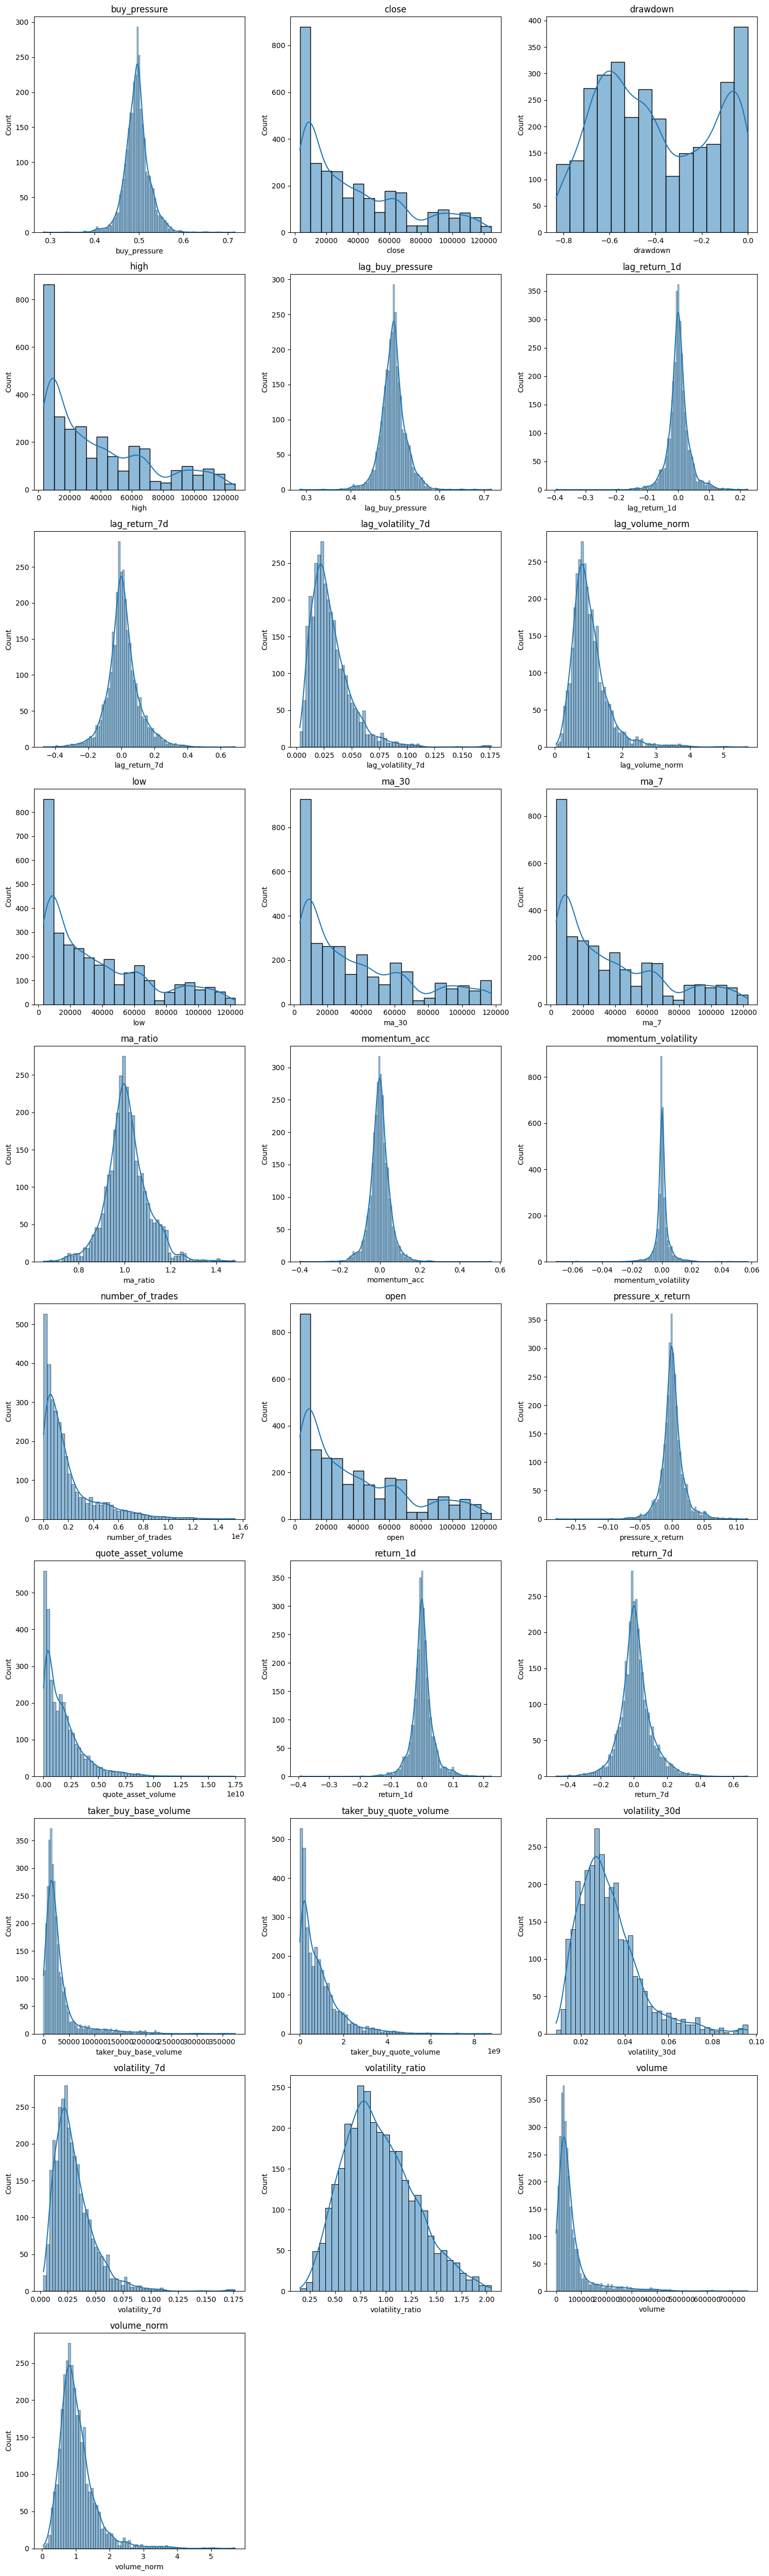

In [10]:
cols = list(df.columns.difference(["open_time", "target"]))

n_cols = 3  # nombre de graphes par ligne
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(col)

# Supprimer les plots vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observations**

- Most price/volume-related features (open, close, volume, trades) are **heavily right-skewed** → need log scaling.
- Returns (`return_1d`, `return_7d`) are **centered around 0 with fat tails** → typical financial distributions.
- Volatility features are **positively skewed** with clear concentration at low values → regime-dependent behavior.
- `drawdown` shows a **multi-modal distribution** → distinct market regimes (bull, correction, bear).
- Lagged features closely mirror original ones → **strong temporal autocorrelation**.
- `buy_pressure` is **approximately Gaussian around 0.5** → relatively stable feature.
- Volume-related features exhibit **extreme outliers** → potential need for clipping or normalization.

**Conclusion**

- Apply **log transforms** to price and volume features to reduce skewness.  
- Use **robust scaling and clipping** to handle fat tails and outliers.  
- Leverage **temporal features (lags, rolling stats)** as key predictive signals.  
- Keep `drawdown` as a **core feature** (captures market regimes).  
- Account for **class imbalance** with appropriate metrics and weighting.  

**Compare distributions between peaks and non-peaks**

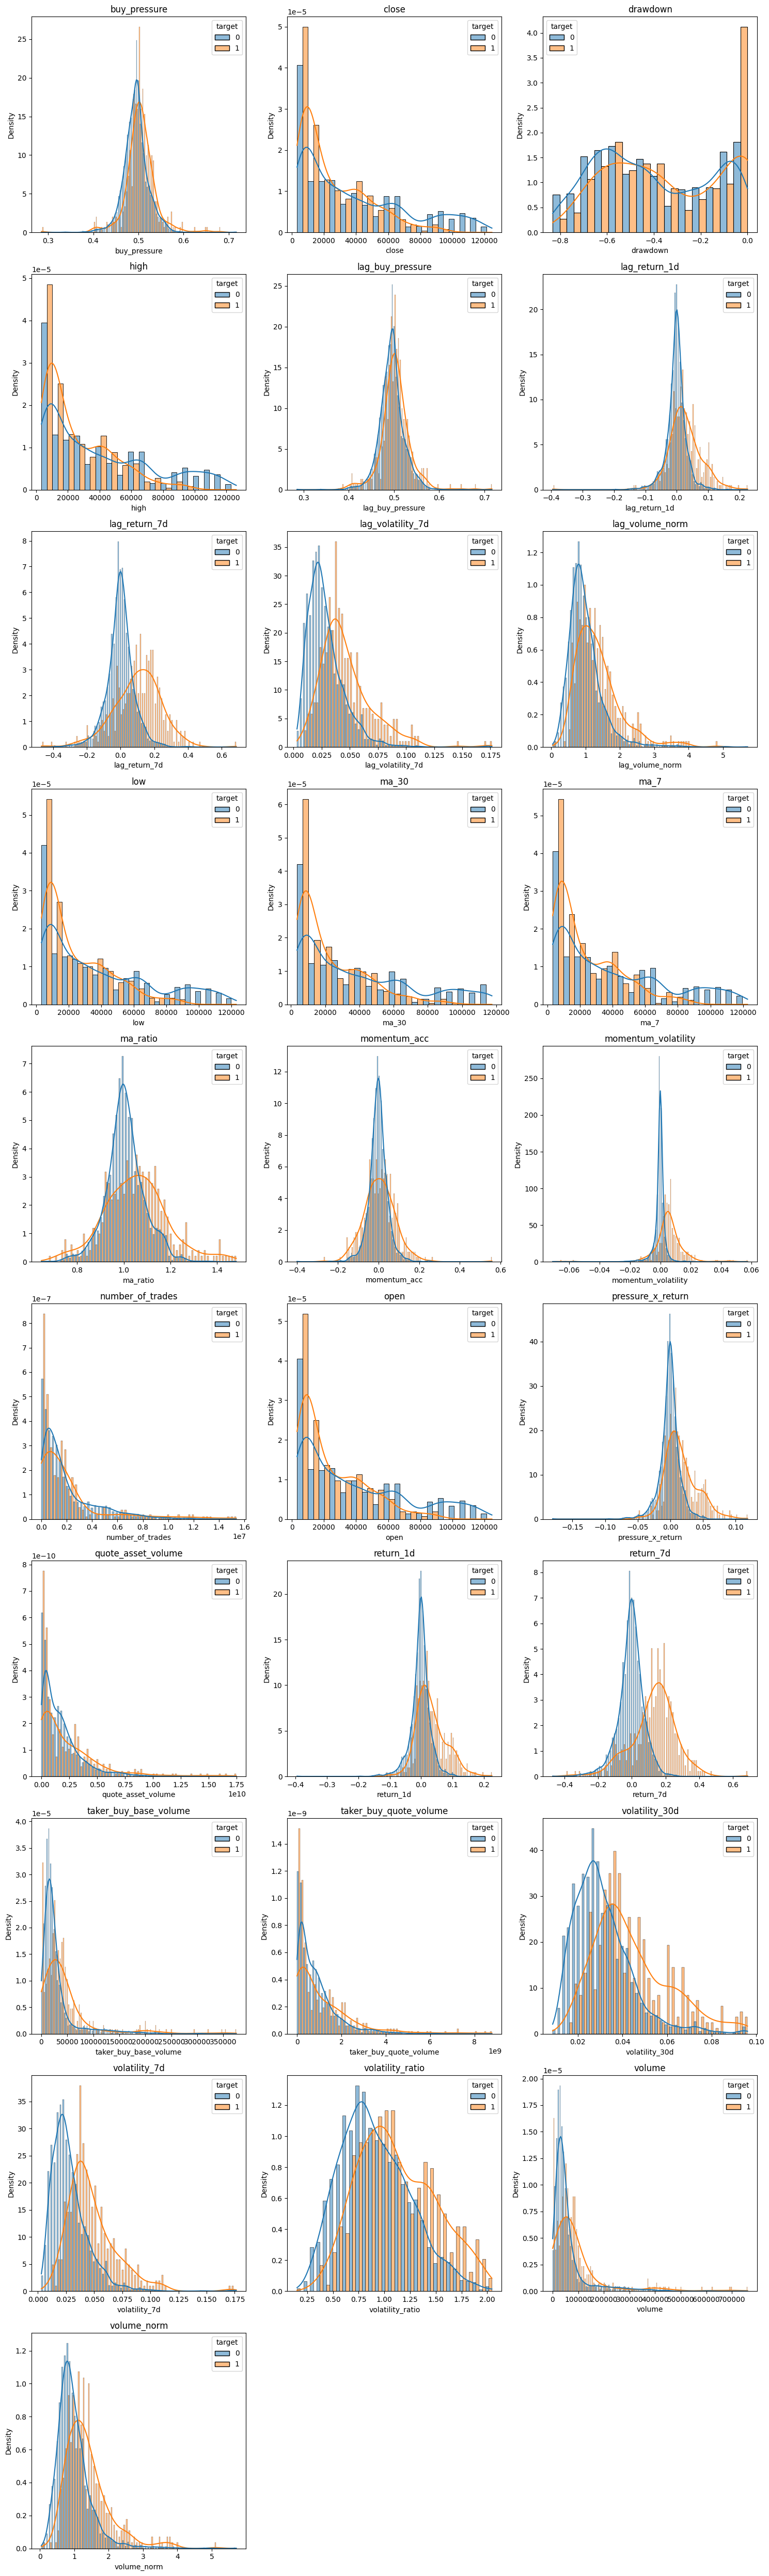

In [11]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        data=df,
        x=col,
        hue="target",
        multiple="dodge",
        ax=axes[i],
        stat="density",
        common_norm=False,
        kde=True
        )
    axes[i].set_title(col)

# Supprimer les plots vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observations**

- Most features show **strong overlap between target classes**, indicating low separability when used individually.
- Returns (`return_1d`, `return_7d`, lagged) are **slightly shifted positive for target=True**, suggesting upward momentum before peaks.
- Volatility features are **higher for target=True**, indicating peaks occur in more unstable market conditions.
- `drawdown` is more concentrated near **0 for target=True**, meaning price is close to its **running historical maximum**.
- Volume-related features show **heavier tails for target=True**, suggesting increased market activity before peaks.
- Lagged features exhibit similar patterns to original ones → confirms **strong temporal dependence**.
- `buy_pressure` shows minimal difference → **weak standalone signal**.


**Conclusion**

- **Drawdown, volatility, and returns are key signals** for peak detection.  
- **Momentum + high volatility + proximity to historical highs** characterize peak regimes.  
- Volume features can help but require **log scaling and outlier handling**.  
- Individual features are weak → need **non-linear models combining signals** (e.g., tree-based).  
- Strong temporal structure → **lag features and time-aware modeling are essential**.  

**Detect unusual behavior before peaks**

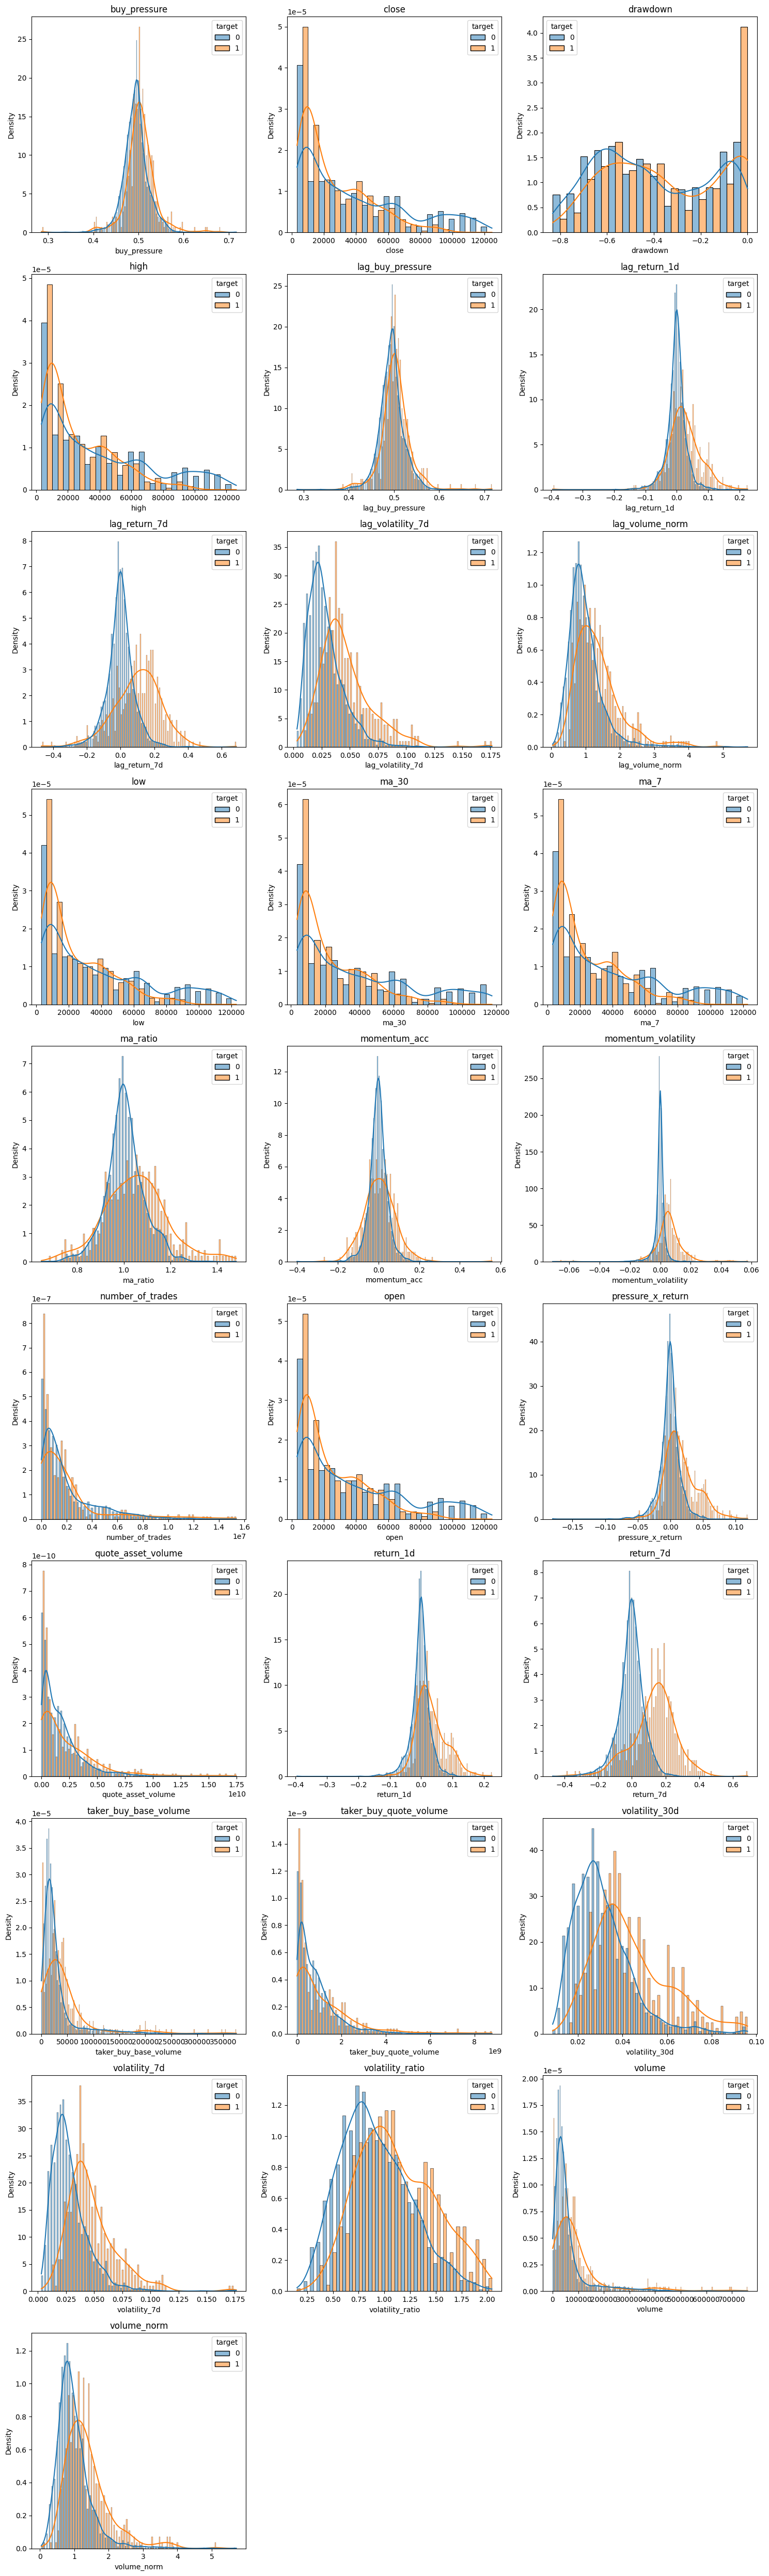

In [12]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        data=df,
        x=col,
        hue="target",
        multiple="dodge",
        ax=axes[i],
        stat="density",
        common_norm=False,
        kde=True
        )
    axes[i].set_title(col)

# Supprimer les plots vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Detect unusual behavior before peaks**

In [ ]:
df["pre_peak_window"] = df["target"].shift(-1) | df["target"].shift(-2) | df["target"].shift(-3) | df["target"].shift(-4) | df["target"].shift(-5)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        data=df,
        x=col,
        hue="pre_peak_window",
        multiple="dodge",
        ax=axes[i],
        stat="density",
        common_norm=False,
        kde=True
        )
    axes[i].set_title(col)

# Supprimer les plots vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for |: 'float' and 'float'

**Observations**

- Most features still show **significant overlap** between normal and pre-peak periods → weak standalone signals.
- Returns (`return_1d`, `return_7d`, lagged) are **slightly more positive before peaks**, indicating momentum buildup.
- Volatility (`volatility_7d`, `volatility_30d`) is **clearly higher and more spread out before peaks** → strong instability signal.
- `drawdown` shifts **closer to 0 before peaks**, confirming peaks occur near historical highs.
- Volume-related features show **heavier right tails before peaks** → increased trading activity and possible FOMO.
- Lagged features reinforce the same patterns → **temporal persistence of signals**.
- `buy_pressure` remains very similar → **low discriminative power**.

**Conclusion**

- **Volatility is the strongest early warning signal** of upcoming peaks.  
- **Momentum (returns)** plays a secondary but consistent role.  
- **Proximity to highs (drawdown ≈ 0)** is a key structural condition.  
- Volume contributes but requires **careful preprocessing**.  
- Signals are **subtle and overlapping**, requiring **non-linear models and feature interactions**.  
- The problem is inherently **temporal**, making lag features essential.  

### **5. Correlation Between Features and Target**

**Objective**
- Identify which features are **most informative for predicting peaks**
- Understand the **direction and strength** of relationships
- Detect **redundant features** to simplify the model

**Methodology**

1. **Feature–Target Analysis**
   - Compute:
     - Pearson → linear relationships  
     - Spearman → monotonic relationships (more robust)  
     - Mutual Information → **non-linear dependencies (essential)**  
   - Rank features using:
     - absolute correlation (Pearson / Spearman)  
     - Mutual Information scores  
   - Analyze direction (using correlation):
     - Positive → feature increases with peak probability  
     - Negative → feature decreases with peak probability  
   - Goal: capture **all types of relationships** between features and target and identify top candidates

2. **Redundancy Check**
   - Compute correlation matrix between features
   - Detect highly correlated pairs (multicollinearity)
   - Keep only one feature per redundant group

3. **Feature Selection**
   - Keep features that are:
     - highly informative (high MI or correlation)  
     - low redundancy  
   - Combine linear and non-linear insights for final selection

**Key Considerations**

- Correlation does **not imply causation**
- Pearson only captures linear relationships  
- Mutual Information is **critical** for detecting complex dependencies  
- This step is **exploratory (EDA)**, not predictive modeling

**Outcome**

- A **refined and robust set of features** for modeling  
- Better understanding of both **linear and non-linear signals** driving peak behavior

In [14]:
# Delete features that are not relevant for the model and that were only used for EDA
df.drop(columns="pre_peak_window", inplace=True)

KeyError: "['pre_peak_window'] not found in axis"

**Feature–Target Dependency**

**Pearson**

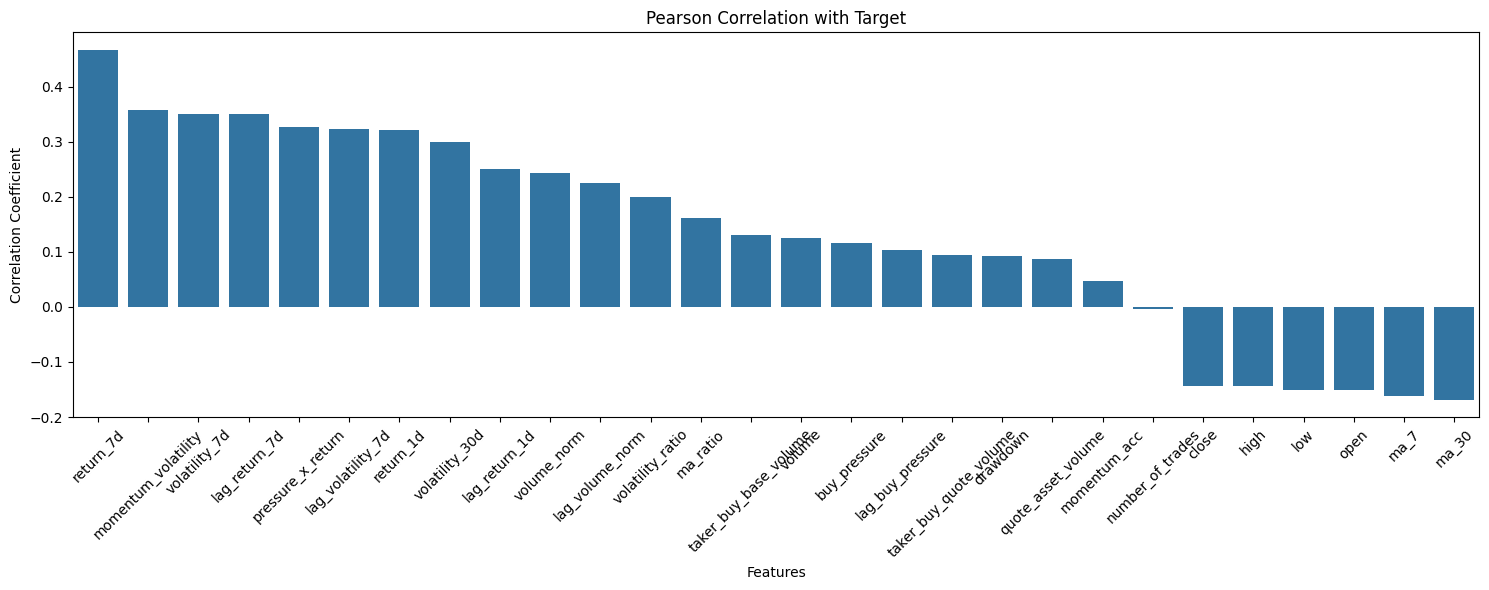

In [15]:
corrs_pearson= df.drop(columns=["open_time"]).corr(method="pearson")["target"].sort_values(ascending=False).drop("target")
plt.figure(figsize=(15, 6))
sns.barplot(x=corrs_pearson.index, y=corrs_pearson.values)
plt.xticks(rotation=45)
plt.title("Pearson Correlation with Target")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

**Observations**

- Overall **weak correlations** (|ρ| < 0.15) → low linear signal  
- **Returns (momentum)** are the most correlated → peaks follow price increases  
- **Volatility** positively correlated → unstable markets precede peaks  
- **Buy pressure** slightly positive → mild pre-peak accumulation  
- **Volume & price levels** ≈ no signal  
- **Trades count** slightly negative → likely noise  

**Conclusion**

- No strong individual predictor  
- Signal is **weak, distributed, and non-linear**  
- Peaks result from **combined effects (momentum + volatility)**  
- Prefer **non-linear models** over linear ones  

**Spearman**

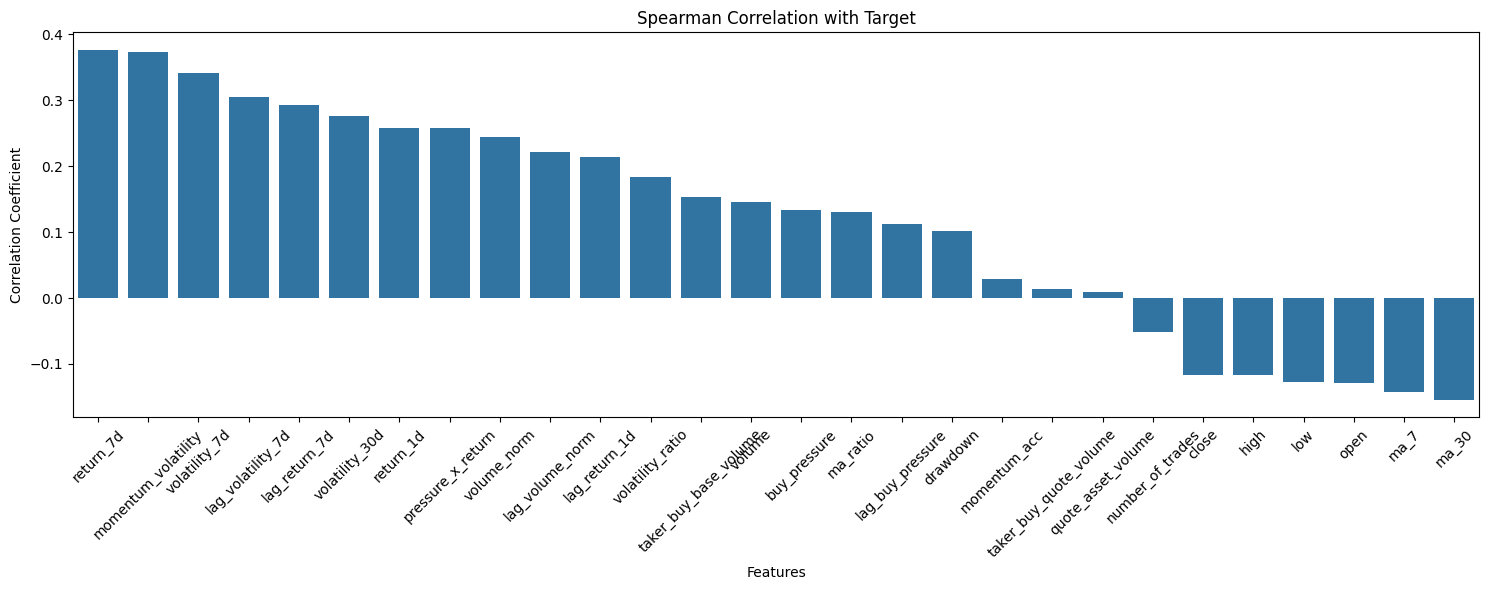

In [16]:
spearman_corrs = df.drop(columns=["open_time"]).corr(method="spearman")["target"].sort_values(ascending=False).drop("target")
plt.figure(figsize=(15, 6))
sns.barplot(x=spearman_corrs.index, y=spearman_corrs.values)
plt.xticks(rotation=45)
plt.title("Spearman Correlation with Target")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

**Observations**

- Weak signal overall (|ρ| < ~0.16)  
- **Returns (momentum)** strongest features  
- **Volatility** positively correlated  
- **Buy pressure** more relevant than in Pearson → non-linear effect  
- **Volume & prices** ≈ no signal  
- **Trades count** slightly negative  

**Conclusion**

- Relationships are **monotonic but weak**  
- Peaks driven by **momentum + volatility + pressure**  
- Need **non-linear models + feature interactions**  

**Mutual Information**

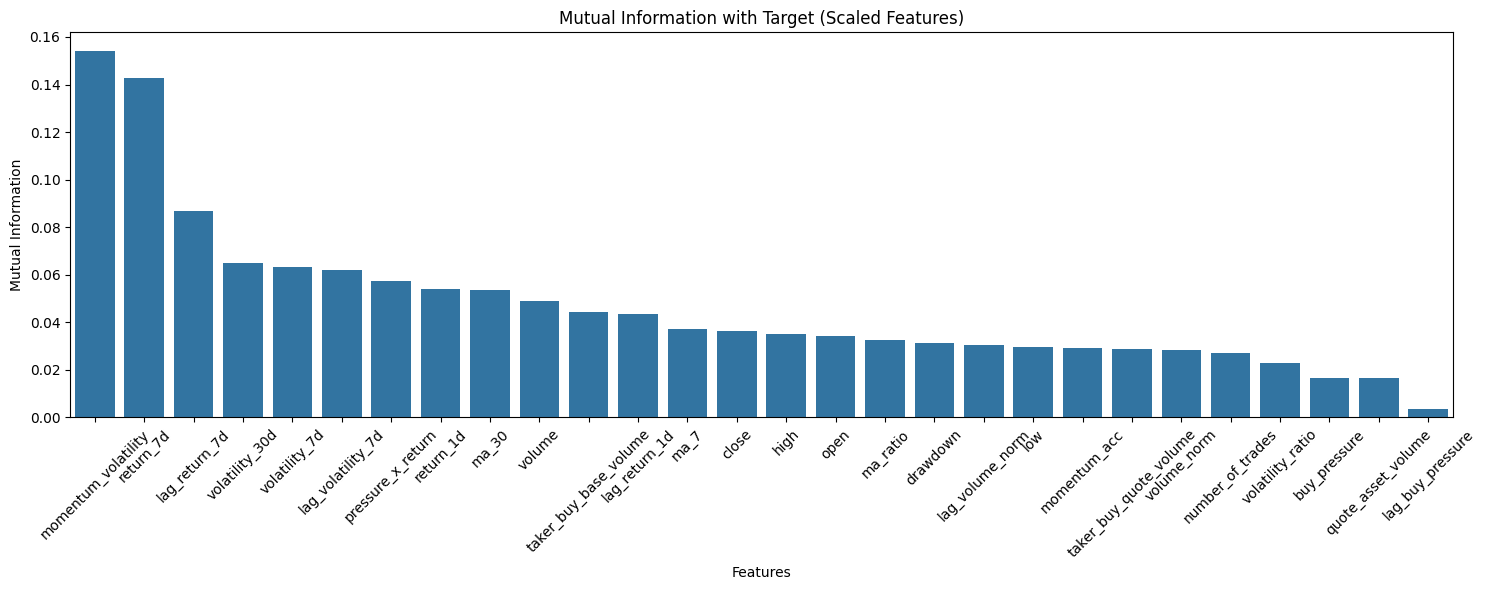

momentum_volatility       0.154246
return_7d                 0.142694
lag_return_7d             0.087018
volatility_30d            0.064804
volatility_7d             0.063392
lag_volatility_7d         0.062044
pressure_x_return         0.057443
return_1d                 0.053969
ma_30                     0.053627
volume                    0.049171
taker_buy_base_volume     0.044229
lag_return_1d             0.043666
ma_7                      0.037237
close                     0.036364
high                      0.034937
open                      0.034140
ma_ratio                  0.032367
drawdown                  0.031474
lag_volume_norm           0.030564
low                       0.029627
momentum_acc              0.029023
taker_buy_quote_volume    0.028761
volume_norm               0.028164
number_of_trades          0.026972
volatility_ratio          0.022860
buy_pressure              0.016566
quote_asset_volume        0.016518
lag_buy_pressure          0.003514
dtype: float64

In [17]:
non_nan_df = df.dropna()

X = non_nan_df.drop(columns=["open_time", "target"])
y = non_nan_df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mutual_info = mutual_info_classif(
    X_scaled,
    y,
    discrete_features=False,
    n_neighbors=5,
    random_state=42
)

mutual_info_series = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x=mutual_info_series.index, y=mutual_info_series.values)
plt.xticks(rotation=45)
plt.title("Mutual Information with Target (Scaled Features)")
plt.ylabel("Mutual Information")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

mutual_info_series

**Redundancy Check**

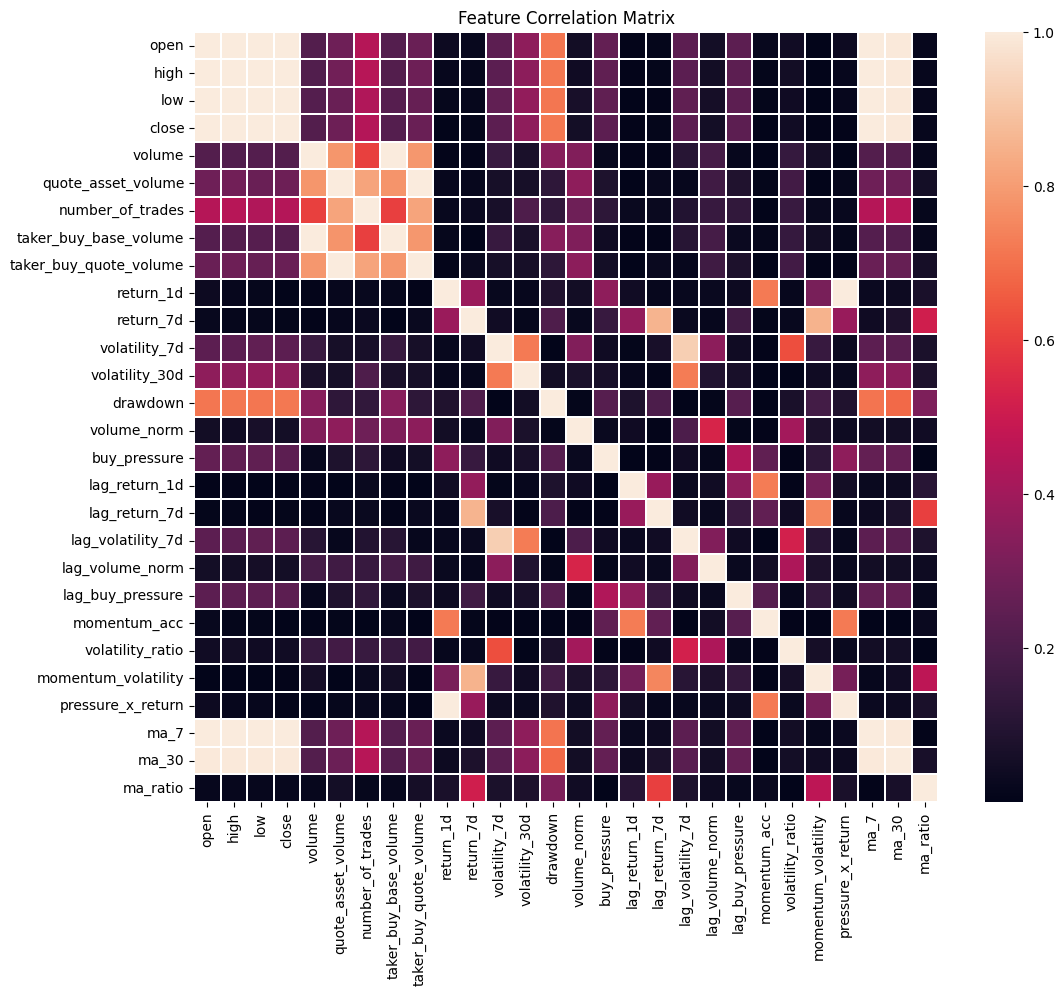

In [18]:
corr_X = X.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_X, linewidths=0.1, fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

**Observations**

- OHLC prices and moving averages (`ma_7`, `ma_30`) are almost perfectly correlated (~0.99) → strong redundancy  
- Volume-related features show high correlations (up to ~1.0), especially between raw and taker volumes → duplicated information  
- Some volatility features are moderately to strongly correlated, especially lagged versions (e.g. `volatility_7d` vs `lag_volatility_7d` > 0.9) → partial redundancy  
- `pressure_x_return` is almost identical to `return_1d` (~0.998) → no added value  
- `momentum_acc` is moderately correlated with `return_1d` (~0.7) → partial redundancy  
- `momentum_volatility` is strongly but not excessively correlated with `return_7d` (~0.85) → below redundancy threshold  
- `ma_ratio` shows very low correlation with price features → provides independent information  
- `buy_pressure` and lagged features exhibit moderate correlations → capture complementary temporal dynamics  

**Conclusions**

- Significant multicollinearity exists in price (OHLC, moving averages) and volume-related features  
- Some engineered features introduce redundancy rather than new information  
- Feature reduction is required to improve model stability and reduce overfitting risk  
- Features should be retained if they capture distinct signals (momentum, ratios, pressure, temporal effects)  
- Strictly redundant features (correlation > 0.9) should be removed, while moderately correlated features can be preserved if they add complementary information  

**Feature Selection**

In [19]:
score = spearman_corrs.abs() / spearman_corrs.abs().max() + mutual_info_series / mutual_info_series.max()
score = score.sort_values(ascending=False)
score

momentum_volatility       1.993283
return_7d                 1.925103
lag_return_7d             1.339930
volatility_7d             1.318308
lag_volatility_7d         1.212973
volatility_30d            1.151952
pressure_x_return         1.056118
return_1d                 1.035879
lag_return_1d             0.852035
volume_norm               0.831664
lag_volume_norm           0.786280
ma_30                     0.758176
volume                    0.705200
taker_buy_base_volume     0.693324
volatility_ratio          0.637705
ma_7                      0.621315
open                      0.563522
ma_ratio                  0.554949
close                     0.546772
high                      0.537732
low                       0.528630
drawdown                  0.474689
buy_pressure              0.461494
lag_buy_pressure          0.320221
number_of_trades          0.311722
momentum_acc              0.266669
taker_buy_quote_volume    0.223796
quote_asset_volume        0.130056
dtype: float64

**Conclusion — Feature Selection (Correlation Threshold = 0.9)**

- A correlation threshold of **0.9** is applied to remove only highly redundant features (near-duplicates), ensuring reduced multicollinearity while preserving most of the useful information.

- The following features are removed due to **correlation > 0.9**:
  - OHLC group → `open`, `high`, `low` (kept: `close`)
  - Moving averages → `ma_7`, `ma_30`
  - Volume duplicates → `taker_buy_base_volume` (kept: `volume`)
  - Strong interaction redundancy → `pressure_x_return` (redundant with `return_1d`)

- The following features are kept:
  - **Momentum** → `return_1d`, `return_7d`  
  - **Volatility** → `volatility_30d`, `volatility_7d`  
  - **Market behavior** → `buy_pressure`  
  - **Risk context** → `drawdown`  
  - **Trend signal** → `ma_ratio`  
  - **Temporal signal** → `lag_return_1d`, `lag_return_7d`, `lag_volatility_7d`, `lag_buy_pressure`, `lag_volume_norm`  
  - **Additional features** → `momentum_acc`, `momentum_volatility`, `volume`, `number_of_trades`, `quote_asset_volume`  

- This selection ensures:
  - removal of only **strictly redundant features**  
  - preservation of **feature diversity**  
  - minimal information loss  

- The dataset is now:
  - cleaner  
  - less collinear  
  - ready for further analysis or modeling  

### **General Conclusion — Exploratory Data Analysis & Feature Engineering**

- The dataset exhibits strong **multicollinearity**, especially among price (OHLC), moving averages, and volume-related features, confirming significant redundancy in raw financial variables.

- Feature engineering introduced several **informative signals**, particularly:
  - **Momentum** (`return_1d`, `return_7d`)
  - **Market behavior** (`buy_pressure`)
  - **Risk context** (`drawdown`)
  - **Trend / regime indicator** (`ma_ratio`)
  - **Temporal dynamics** (lag features)

- Some engineered features (notably interaction terms such as `pressure_x_return`) were found to be **nearly identical to simpler variables**, and were therefore removed to avoid redundancy.

- A **correlation-based filtering (threshold = 0.9)** was applied to remove strictly redundant features (near-duplicates), ensuring:
  - reduced multicollinearity  
  - preservation of complementary signals  
  - minimal information loss  

- Feature importance methods (Spearman correlation and Mutual Information) are **not used at this stage** to avoid data leakage and will be applied later **on the training set only** during modeling.

### **Final Selected Features**

The following features are retained for modeling:

- **Momentum**
  - `return_1d`, `return_7d`

- **Volatility**
  - `volatility_7d`, `volatility_30d`

- **Market behavior**
  - `buy_pressure`

- **Risk context**
  - `drawdown`

- **Trend / regime**
  - `ma_ratio`

- **Temporal (lag features)**
  - `lag_return_1d`, `lag_return_7d`
  - `lag_volatility_7d`
  - `lag_buy_pressure`
  - `lag_volume_norm`

- **Additional signals**
  - `momentum_acc`
  - `momentum_volatility`
  - `volume`
  - `number_of_trades`
  - `quote_asset_volume`

### **Final Dataset Characteristics**

- Reduced feature space with **lower redundancy**
- Preserved **diversity of signals** (momentum, volatility, behavior, temporal)
- Improved **interpretability and stability** for modeling

- The target variable represents a **rare event (~2%)**, making this a **rare-event classification problem**, which requires:
  - appropriate evaluation metrics (PR-AUC, Recall)  
  - handling of class imbalance  

### **Conclusion**

The dataset is now **clean, structured, and ready for modeling**, with:
- meaningful and non-redundant features  
- controlled multicollinearity  
- a solid foundation for robust model benchmarking and further optimization  